In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
hep.style.use("CMS")

import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip

## Saved Models for different configuration
### If you have multiple models, this is where you can list them

In [2]:
# Format is (particle, input feature dimensions, output feature dimensions, use classification, granularity)
conditions = {
    ('rho/pion', '4D', '1D', True, "high_granularity"):{
    'result_dir': '/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/highgranularity_rho_pi_120epochs_regresssion.75_classification.25/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/highgranularity_rho_pi/'
    },
    ('rho/pion', '4D', '1D', True, "low_granularity"):{
    'result_dir': '/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/lowgranularity_rho_pi/',
    'preprocessed_dir': '/media/miguel/Elements_2024/AI_data/preprocessed_data/ePIC_preprocessed/lowgranularity_rho_pi/'
    },
}
default_entry = {
    'result_dir': 'No_File',
    'preprocessed_dir': 'No_Title',
}

### Pick the model you want based on options

In [3]:
particle ='rho/pion'  # pi+,  pi0, neutron, gamma
input_features='4D'  ## input features [4D, 2D, 1D]
output_dim='1D'    ## '1D', '2D', '3D'
classification = True
granularity="high_granularity"
entry = conditions.get((particle,
                        input_features,
                        output_dim,
                        classification,
                        granularity),
                       default_entry)
path_to_result = entry['result_dir']
path_to_stat = entry['preprocessed_dir']

if entry['result_dir'] == 'No_File':
    print('File not found')    

print(path_to_result)  

/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_results/highgranularity_rho_pi_120epochs_regresssion.75_classification.25/


### Get model's predictions and target variables

In [4]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz", allow_pickle=True) 

predictions_unnormalized = npz_unpacked['outputs_scaled'].item()
targets_unnormalized = npz_unpacked['targets_scaled'].item()
predictions = npz_unpacked['outputs'].item()
targets = npz_unpacked['targets'].item()
meta = npz_unpacked['meta']
if output_dim == '3D':
    targets_energy = targets_unnormalized["momentum"]
    targets_theta = targets_unnormalized["theta"]
    targets_phi = targets_unnormalized["phi"]

    predictions_energy = predictions_unnormalized["momentum"]
    predictions_theta = predictions_unnormalized["theta"]
    predictions_phi = predictions_unnormalized["phi"]
elif output_dim == '2D':
    targets_energy = targets_unnormalized["momentum"]
    targets_theta = targets_unnormalized["theta"]

    predictions_energy = predictions_unnormalized["momentum"]
    predictions_theta = predictions_unnormalized["theta"]
elif output_dim == '1D':
    if granularity == "low_granularity":
        targets_energy = targets_unnormalized["momentum"][:,0]
        predictions_energy = predictions_unnormalized["momentum"][:,0]
    else:
        targets_energy = targets_unnormalized["momentum"]
        predictions_energy = predictions_unnormalized["momentum"]
else:
    print("Output dimensions isn't 1D, 2D, or 3D")
    
if classification:
    targets_classification = targets["classification"]
    predictions_classification = predictions["classification"]
# Obtaining the file names and event numbers for each entry
# meta_info_initial = npz_unpacked['meta']
# meta_info =[]
# # The saved meta is in the form of [file_name, event_num,  particle_name, file_name, event_num, particle_name ...]
# # Put it in the form [(file_name, event_num, particle_name), (file_name, event_num, particle_name), ...]
# # This aligns its length with the lengths of targets and predictions
# for i, element in enumerate(meta_info_initial):
#     if i%3 == 0:
#         file_name = meta_info_initial[i]
#         event_num = int(meta_info_initial[i+1])
#         particle_name = meta_info_initial[i+2]
#         # putting the file names and event numbers into a tuple
#         meta_tuple = (file_name, event_num, particle_name) 
#         meta_info.append(meta_tuple)
#     else:
#         continue
# # Data type for each entry is (string, int), i.e. (object, int)
# meta_info = np.asarray(meta_info, dtype='object,int,object') 

In [5]:
import vector
import uproot
def rotateY(xdata, zdata, angle):
    s = np.sin(angle)
    c = np.cos(angle)
    rotatedz = c*zdata - s*xdata
    rotatedx = s*zdata + c*xdata
    return rotatedx, rotatedz
def get_eta(meta_info):
    eta_list = np.array([None]*len(meta_info))
    file_and_eventnumber_to_index = {}
    file_names = meta_info[:, 0]
    unique_file_names = np.unique(file_names)
    for unique_name in unique_file_names:
        file_and_eventnumber_to_index[unique_name] = {}
    for i, (file_name, event_number, particle_type) in enumerate(meta_info):
        file_and_eventnumber_to_index[file_name][event_number] = i
    
    for file_name in unique_file_names:
        print(f"Opening {file_name}")
        with uproot.open(file_name+":events") as f:
            mcparticles_arrays = f.arrays(["MCParticles.momentum.x", "MCParticles.momentum.y", "MCParticles.momentum.z", "MCParticles.mass", "MCParticles.generatorStatus", "MCParticles.PDG"])
        if "rhodecay" in file_name:
            mask = (mcparticles_arrays["MCParticles.generatorStatus"]==2) & (mcparticles_arrays["MCParticles.PDG"]==113)
        else:
            mask = mcparticles_arrays["MCParticles.generatorStatus"]==1
        mcparticles_arrays = mcparticles_arrays[mask]
        momentum_x, momentum_z = rotateY(mcparticles_arrays["MCParticles.momentum.x"], mcparticles_arrays["MCParticles.momentum.z"], .025)
        momentum_y = mcparticles_arrays["MCParticles.momentum.y"]
        momentum = np.sqrt(momentum_x**2 + momentum_y**2 + momentum_z**2)
        theta = np.arccos(momentum_z/momentum)
        eta = -np.log(np.tan(theta/2))
        for i, eta_value in enumerate(eta):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                eta_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = eta_value[0]
            else:
                continue
    return eta_list

In [6]:
eta = get_eta(meta)

Opening /media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_pi+_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_20_2025/reco_pi+_discrete_1GeV-150GeV_theta_2.3deg-4.25deg_0.edm4hep.root
Opening /media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_pi+_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_20_2025/reco_pi+_discrete_1GeV-150GeV_theta_2.3deg-4.25deg_1.edm4hep.root
Opening /media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_pi+_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_20_2025/reco_pi+_discrete_1GeV-150GeV_theta_2.3deg-4.25deg_10.edm4hep.root
Opening /media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_pi+_log10discrete_1GeV-150GeV_2.3deg-4.25deg_08_20_2025/reco_pi+_discrete_1GeV-150GeV_theta_2.3deg-4.25deg_11.edm4hep.root
Opening /media/miguel/Elements_2024/AI_data/datasets/ePIC_data/epicforward_inserthighgranularity_pi+_log10discrete_1GeV-15

In [7]:
print(targets_energy.shape, predictions_energy.shape, targets_classification.shape, predictions_classification.shape, eta.shape)

(948794,) (948794,) (948794,) (948794,) (948794,)


### Inspect loss curve

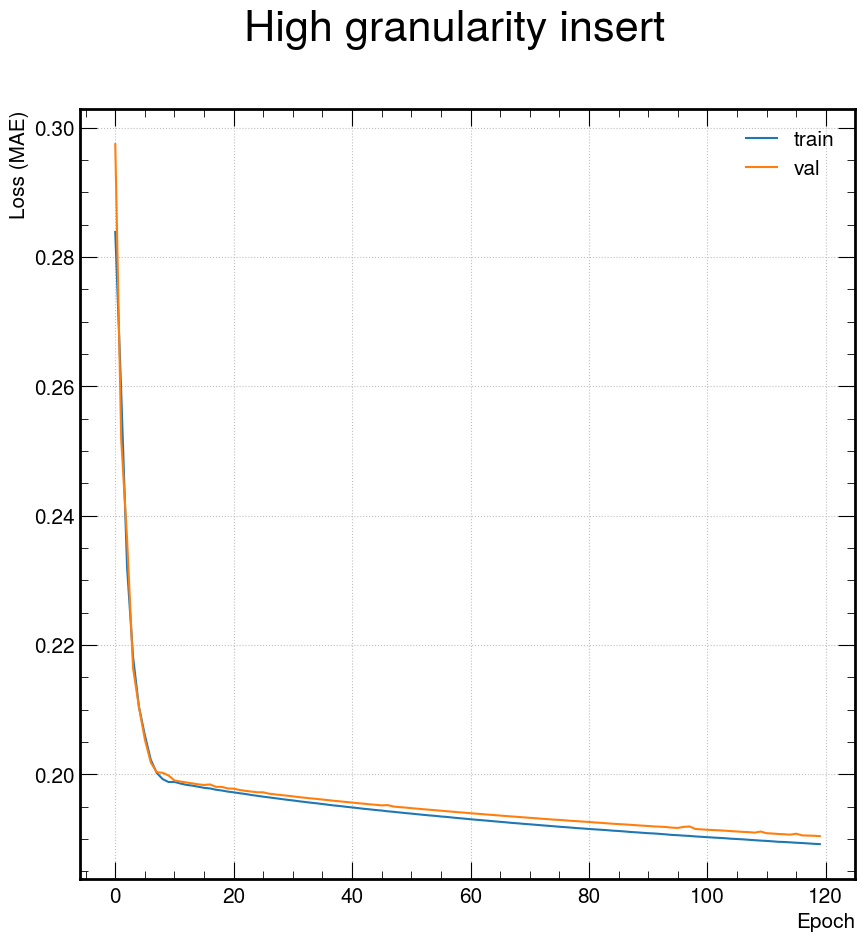

In [8]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()
if granularity=="high_granularity":
    plt.suptitle(f"High granularity insert")
elif granularity=="low_granularity":
    plt.suptitle(f"Low granularity insert")

### Creating bins based on energies of the test data

In [9]:
# Returns a sorted array of unique target energies
energy_bins = np.unique(np.round(targets_energy).astype(int))
energy_mask = (energy_bins > 15) & (energy_bins <  500)
energy_bins = energy_bins[energy_mask]
print(energy_bins)

[ 17  20  23  26  31  35  41  47  55  63  73  84  97 112 129 150]


In [10]:
def plot_classification(energies, truth, pred, binning, nbins, id_cut, particle0_name, particle1_name, eta = None, eta_low = None, eta_high = None):   
    # id_cut is the number below which the model number will be called a photon, above which it is a pi0
    print(len(energies), len(truth), len(pred))
    N_Bins=len(binning)
    row=math.ceil(np.sqrt(N_Bins-1))
    if (row**2-N_Bins)>1:
        col=row-1
    else:
        col=row

    xtitle='Predicted particle'
    y_ticks_size=14
    x_ticks_size=14
    
    fig,axs = plt.subplots(row,col, figsize=(24, 20),sharex=False)#,constrained_layout=True)
    plt.subplots_adjust(wspace=0, hspace=0.35)
    if (len(truth) != len(pred)):
        print("truth and prediction arrays must be same length")
    energies=np.rint(energies)
    mask = (energies >= binning[0]) & (energies <= binning[-1])
    energies = energies[mask]
    truth = truth[mask]
    pred = pred[mask]
    
    if eta_low is not None or eta_high is not None:
        eta = eta[mask]
        eta_mask = np.ones_like(eta, dtype=bool)
        if eta_low is not None:
            eta_mask = (eta_mask) & (eta>eta_low)
        if eta_high is not None:
            eta_mask = (eta_mask) & (eta<eta_high)
        energies = energies[eta_mask]
        truth = truth[eta_mask]
        pred = pred[eta_mask]
    
    indecies = np.digitize(energies,binning)-1 #Get the bin number each element belongs to.
    indecies=np.where(indecies < 0, 0, indecies) # Returns array with # of entries in each bin [num bin0, num bin1, ..., num N_Bins-1]
    max_count = np.bincount(indecies).max() # Grabs the number of entries that's the most
    slices = np.empty((N_Bins,max_count+1)) # Slices is an array of N_Bins length, each with max_count entries
    slices.fill(np.nan)
    slices_truth=np.empty((N_Bins,max_count+1))
    slices_truth.fill(np.nan)
    
    counter = np.zeros(N_Bins,int) #for getting mean from sum, and incrementing element number in bin                                                                
    
    for i in range(len(energies)):
        bin = indecies[i]
        if (bin>=N_Bins): continue
        slices[bin][counter[bin]] = pred[i] #slice_array[bin number][element number inside bin] = pred[i]                                                            
        slices_truth[bin][counter[bin]] = truth[i]        
        counter[bin]+=1
    
    counter[counter == 0] = 1
    particle0_accuracy = np.zeros(N_Bins)
    particle1_accuracy = np.zeros(N_Bins)
    total_accuracy = np.zeros(N_Bins)
    particle0_misidentification = np.zeros(N_Bins)
    particle1_misidentification = np.zeros(N_Bins)
    total_misidentification = np.zeros(N_Bins)

    for ii in range(N_Bins):
                                   
        irow=int(ii/col)
        icol=int(ii%col)
        
        if irow<row:
            
            ax = axs[irow,icol]
            count_particle0, bins_particle0,_ = ax.hist(slices[ii].ravel()[slices_truth[ii].ravel()==0],bins=nbins,alpha=0.5,range=(0,1),label=f'{particle0_name}',color='b',linewidth=8)
            count_particle1, bins_particle1, _ = ax.hist(slices[ii].ravel()[slices_truth[ii].ravel()==1],bins=nbins,alpha=0.5,range=(0,1),label=f'{particle1_name}',color='r',linewidth=8)

            count_particle0=count_particle0[~np.isnan(count_particle0)]
            bins_particle0=bins_particle0[~np.isnan(bins_particle0)]
            binscenters_particle0 = np.array([0.5 * (bins_particle0[i] + bins_particle0[i+1]) for i in range(len(bins_particle0)-1)])
            
            count_particle1=count_particle1[~np.isnan(count_particle1)]
            bins_particle1=bins_particle1[~np.isnan(bins_particle1)]
            binscenters_particle1 = np.array([0.5 * (bins_particle1[i] + bins_particle1[i+1]) for i in range(len(bins_particle1)-1)])
            if not np.array_equal(binscenters_particle0, binscenters_particle1):
                print("Binning between particle0 and particle1 is not the same!")
            
            total_particle0_events = np.sum(count_particle0)
            total_particle1_events = np.sum(count_particle1)
            
            for i_bin, bin_value in enumerate(binscenters_particle0):
                if bin_value < id_cut or bin_value == id_cut:                    
                    particle0_accuracy[ii] += count_particle0[i_bin]
                    total_accuracy[ii] += count_particle0[i_bin]
                    particle1_misidentification[ii] += count_particle1[i_bin]
                    total_misidentification[ii] += count_particle1[i_bin]
                elif bin_value > id_cut:
                    particle1_accuracy[ii] += count_particle1[i_bin]
                    total_accuracy[ii] += count_particle1[i_bin]
                    particle0_misidentification[ii] += count_particle0[i_bin]

            particle0_accuracy[ii] /= total_particle0_events
            particle1_accuracy[ii] /= total_particle1_events
            total_accuracy[ii] /= (total_particle0_events + total_particle1_events)
            particle0_misidentification[ii] /= total_particle0_events
            particle1_misidentification[ii] /= total_particle1_events
            total_misidentification[ii] /= (total_particle0_events + total_particle1_events)

            ax.legend(title="Incident particle")
            ax.set_title("{0} GeV".format(binning[ii]), fontsize=15)
            ax.tick_params(axis='x', labelsize=x_ticks_size)
            ax.tick_params(axis='y', labelsize=y_ticks_size)
            # ax.set_ylim(0,5000)
        else:
            continue
    fig.add_subplot(111, frameon=False)
    plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
    plt.xlabel("$\\rho^0$ probability", fontsize=24, labelpad=20)
    plt.ylabel("Entries", fontsize=24, labelpad=20)
            
    return particle0_accuracy, particle1_accuracy, total_accuracy, particle0_misidentification, particle1_misidentification, total_misidentification

(array([ 78876., 104550., 115123., 116811., 113939., 107486.,  97405.,
         86867.,  72147.,  55590.]),
 array([3.2939969 , 3.35543023, 3.41686356, 3.47829689, 3.53973022,
        3.60116355, 3.66259688, 3.72403021, 3.78546354, 3.84689687,
        3.9083302 ]),
 <BarContainer object of 10 artists>)

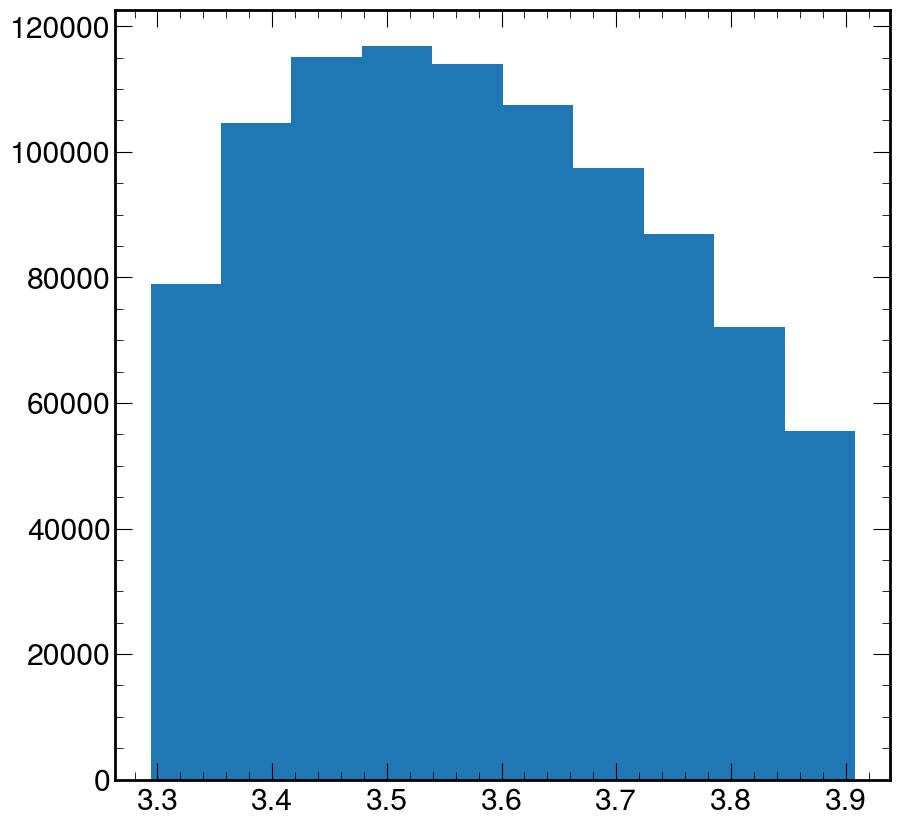

In [11]:
plt.hist(eta)

948794 948794 948794
948794 948794 948794
948794 948794 948794
948794 948794 948794


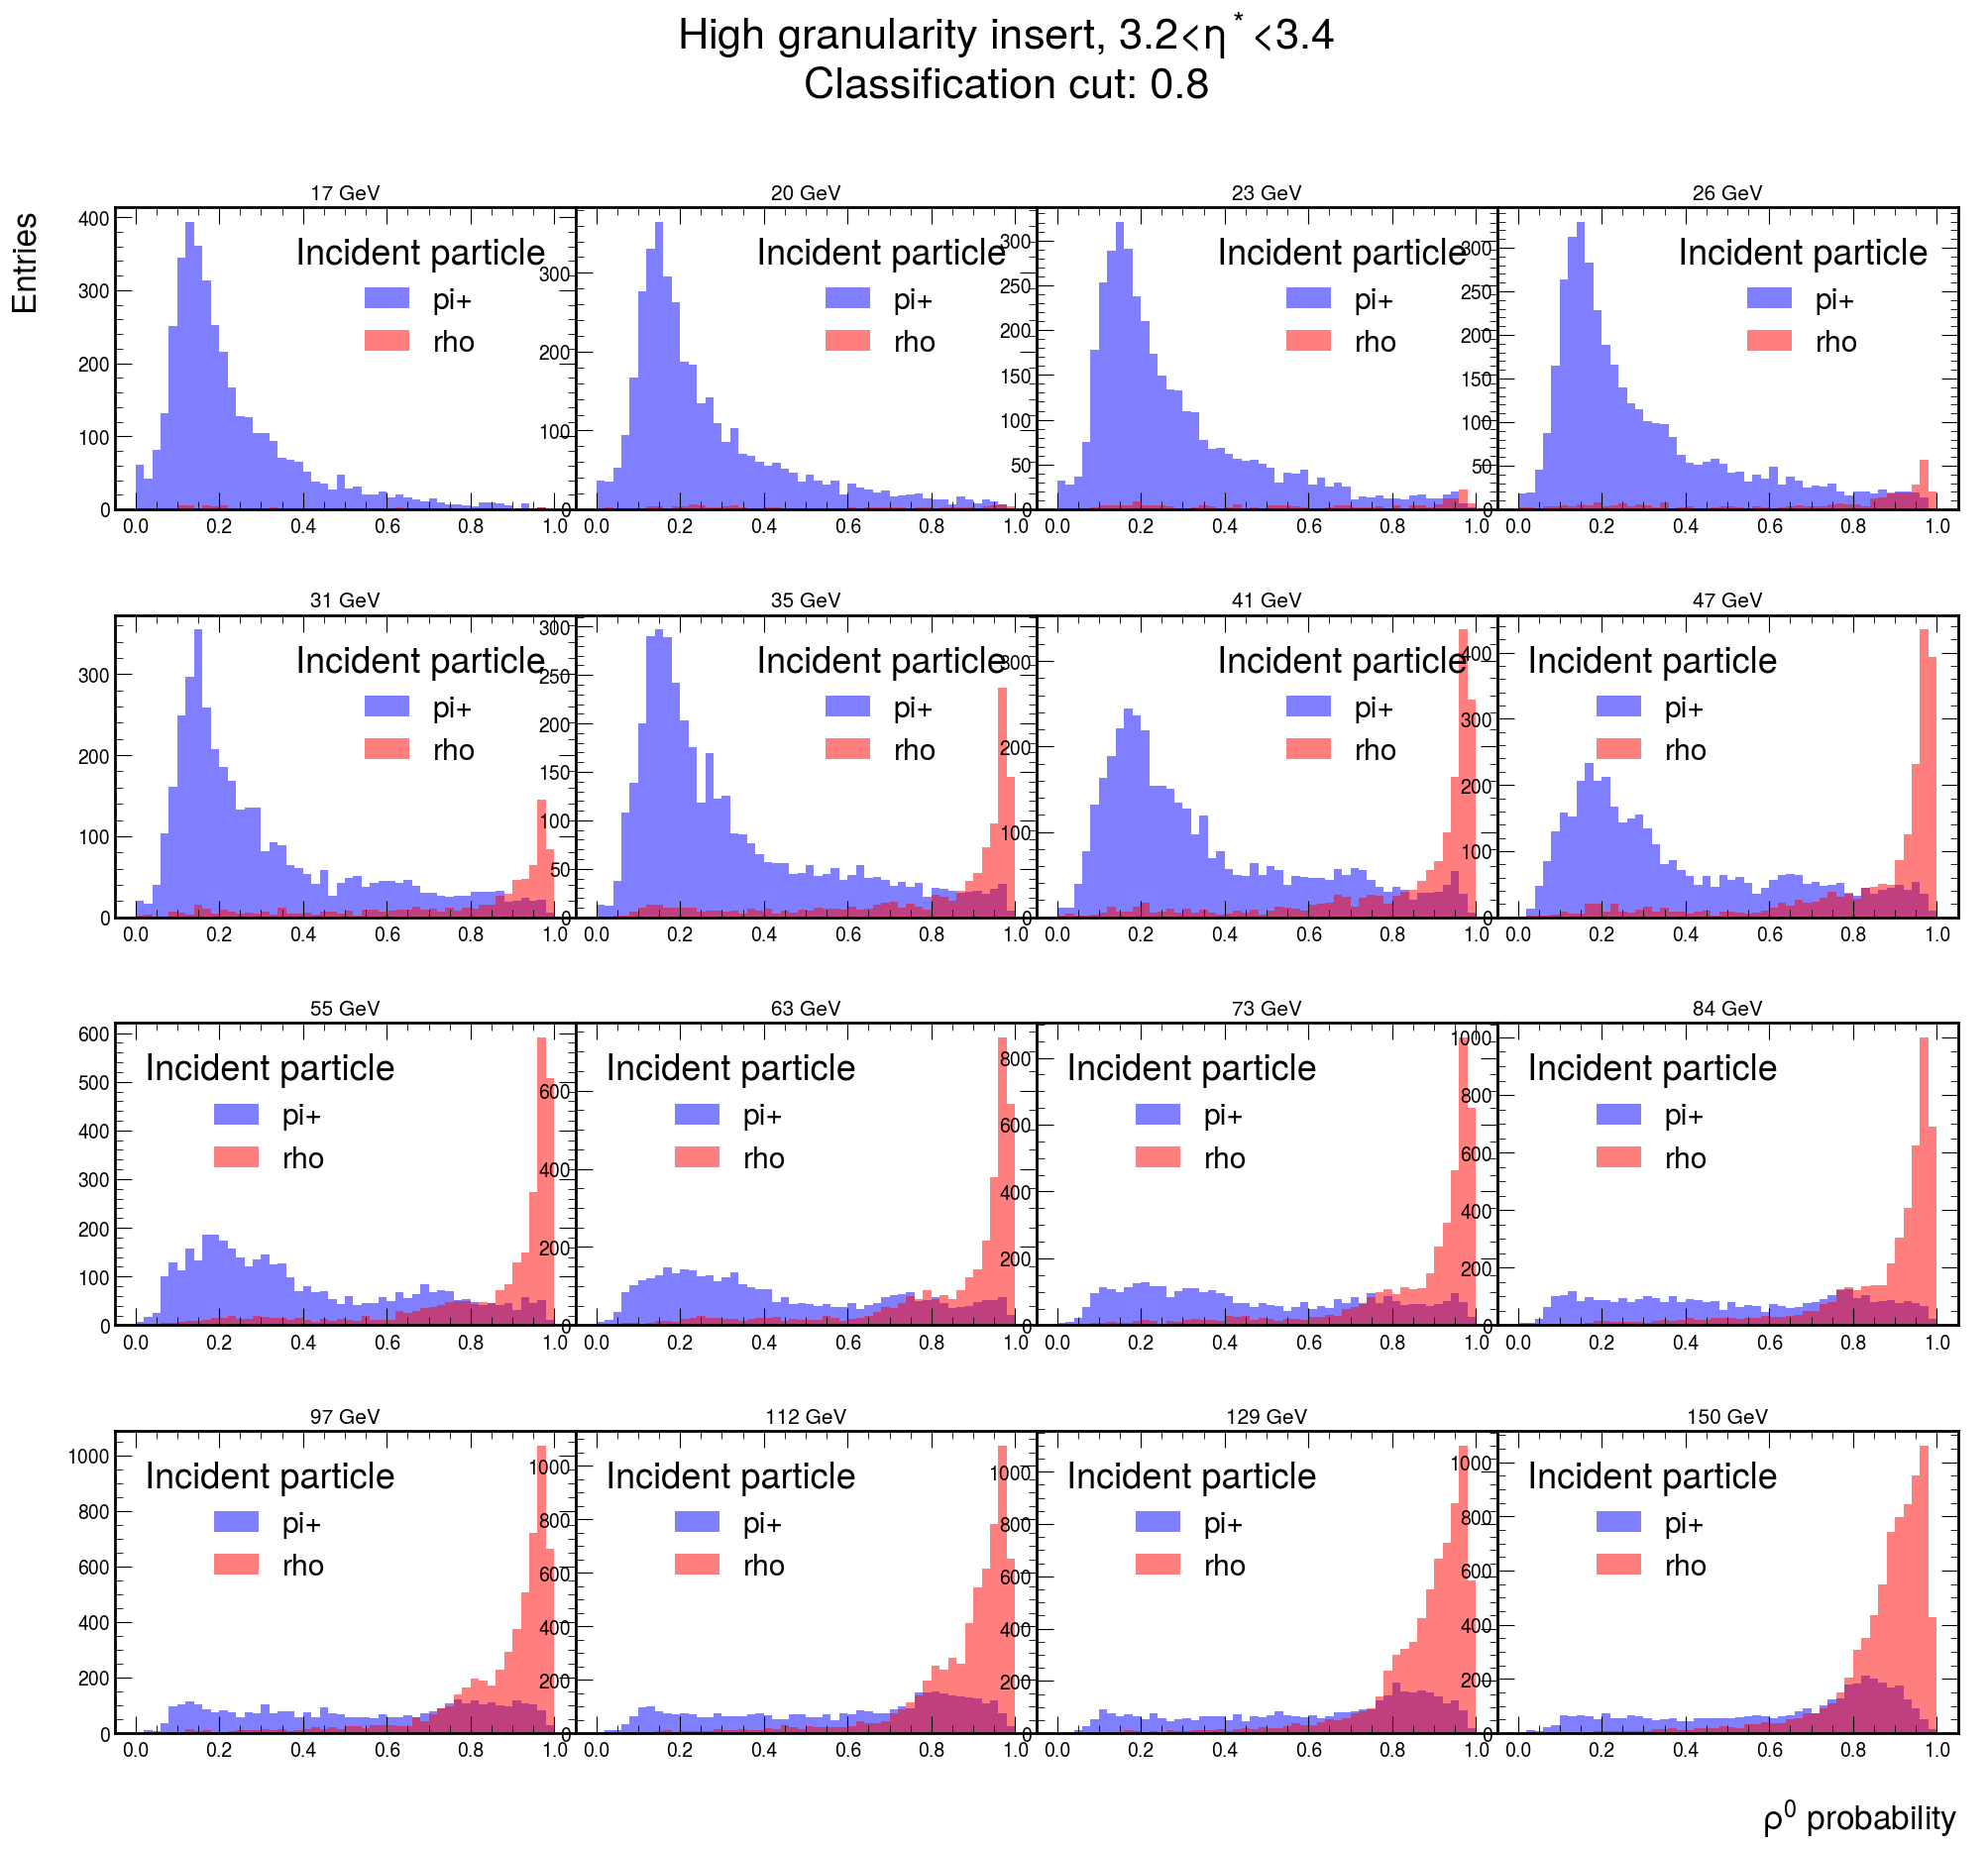

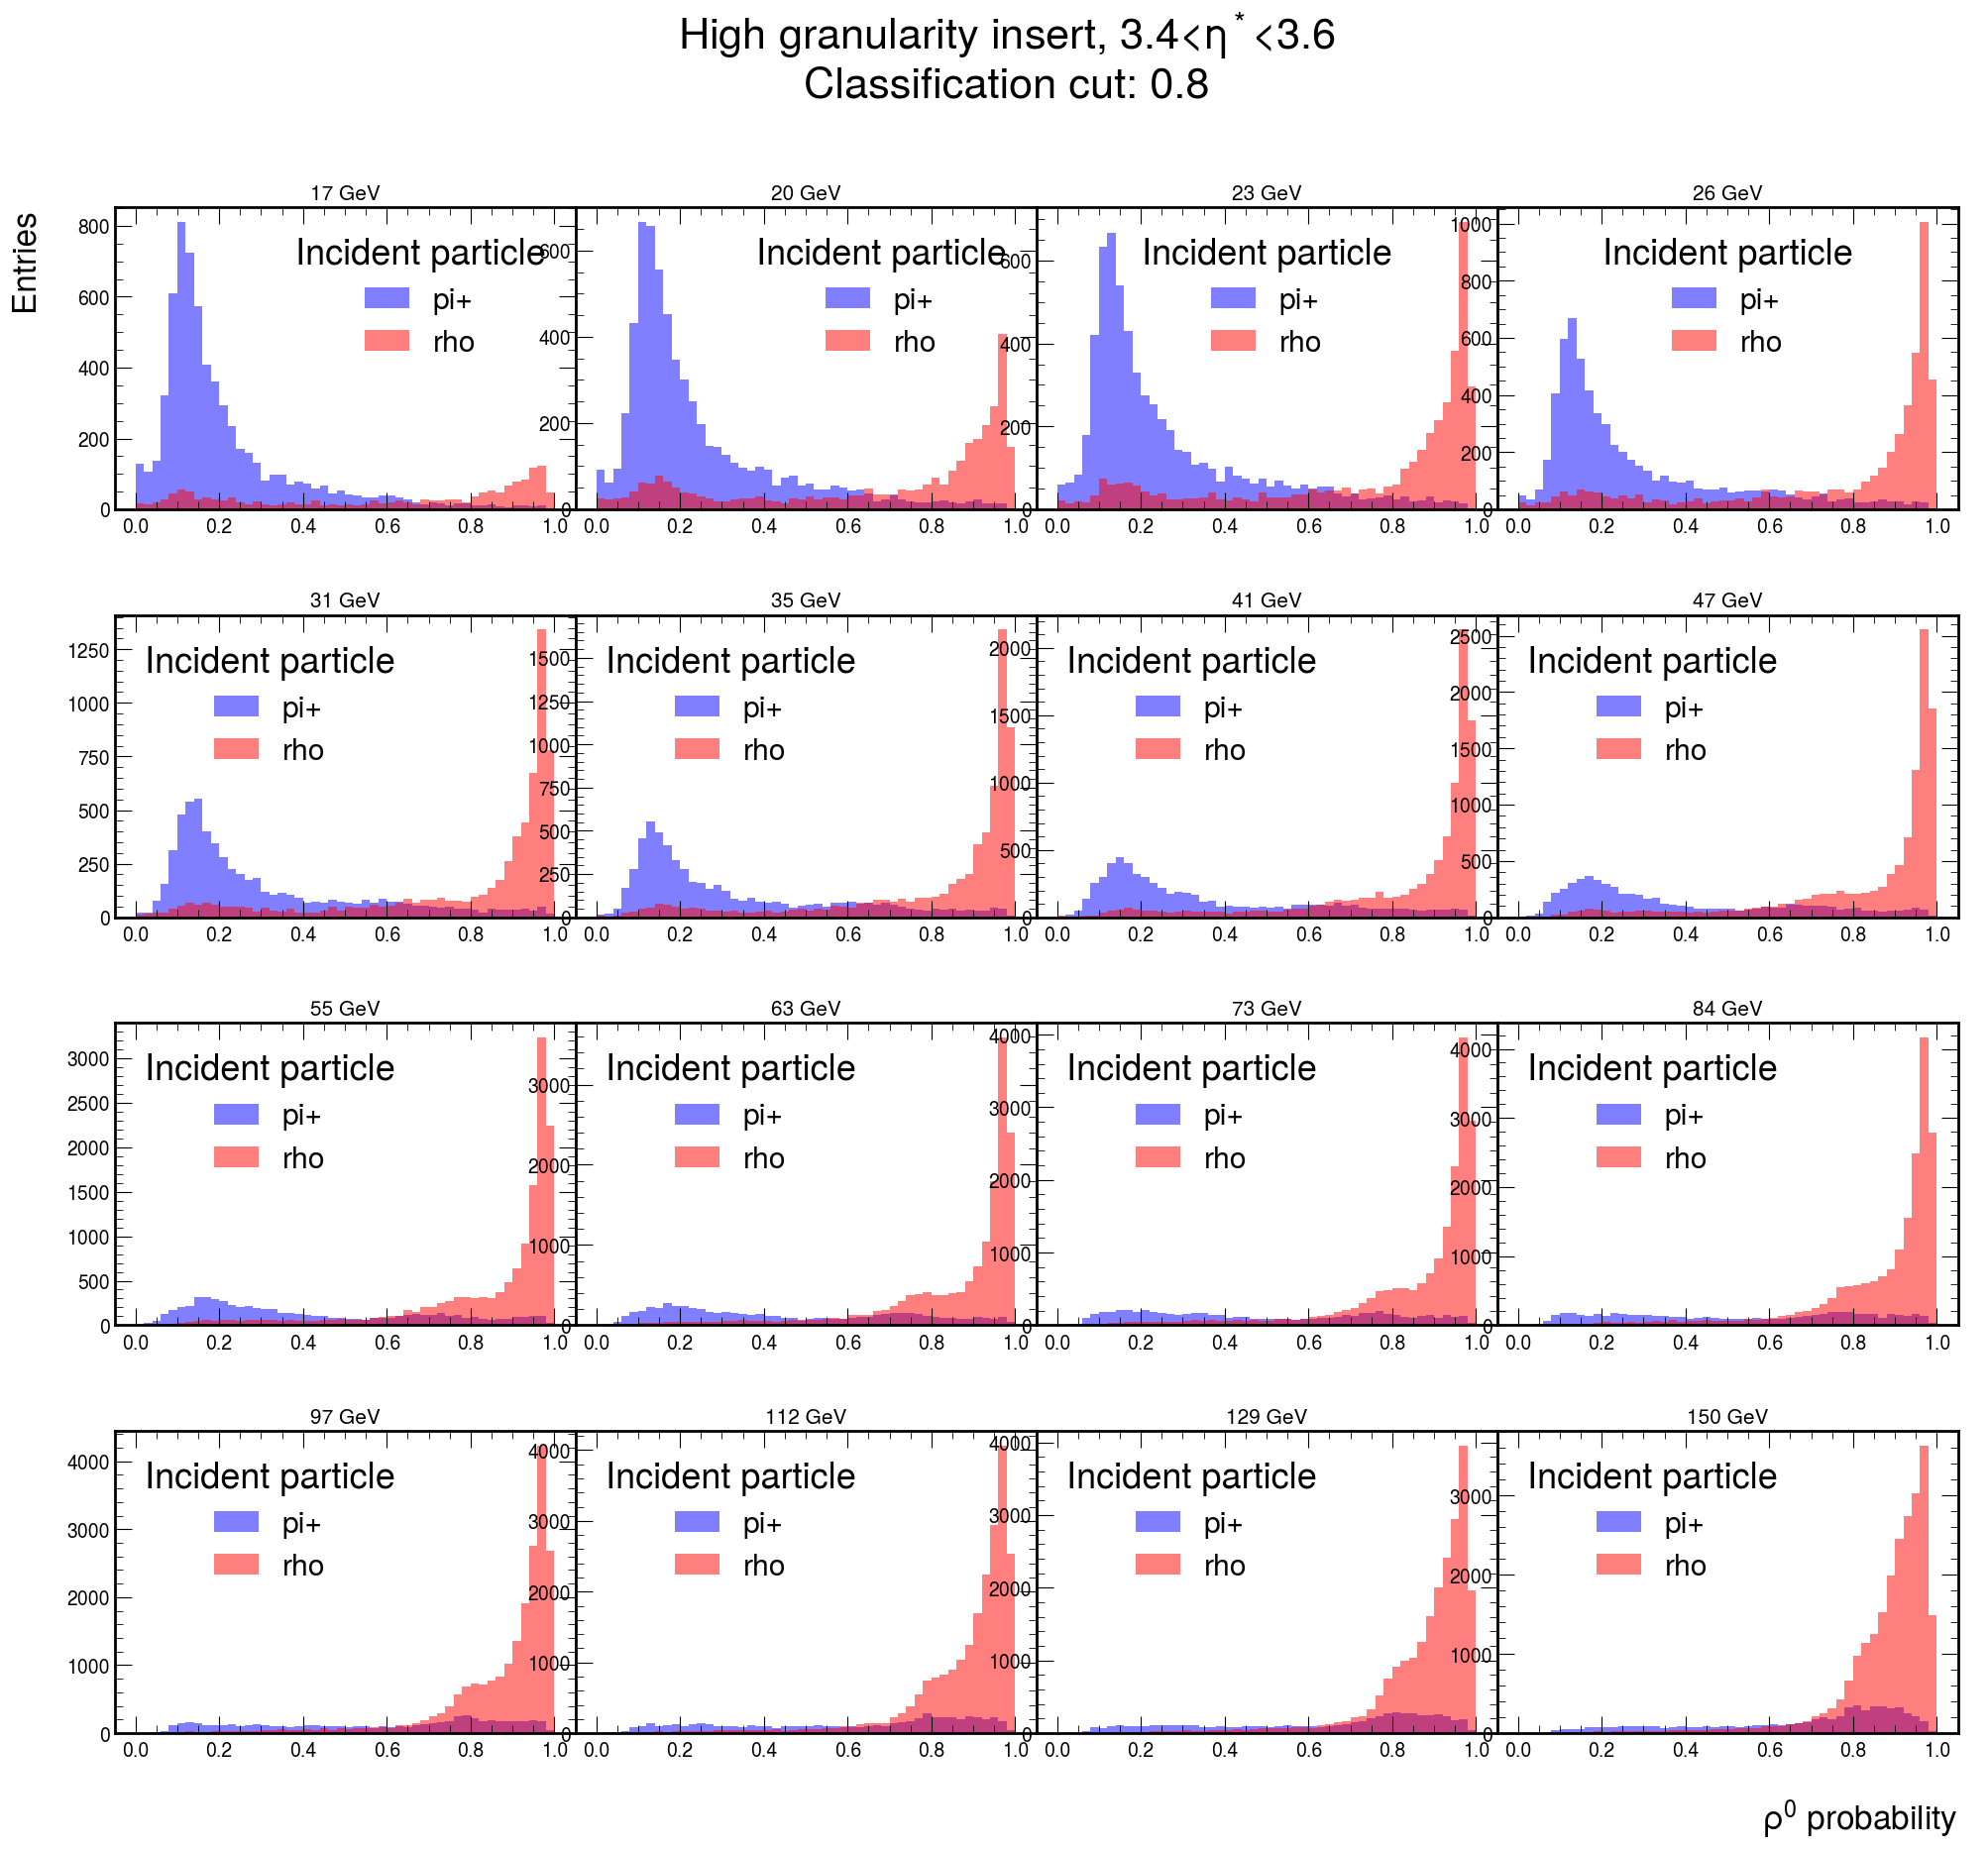

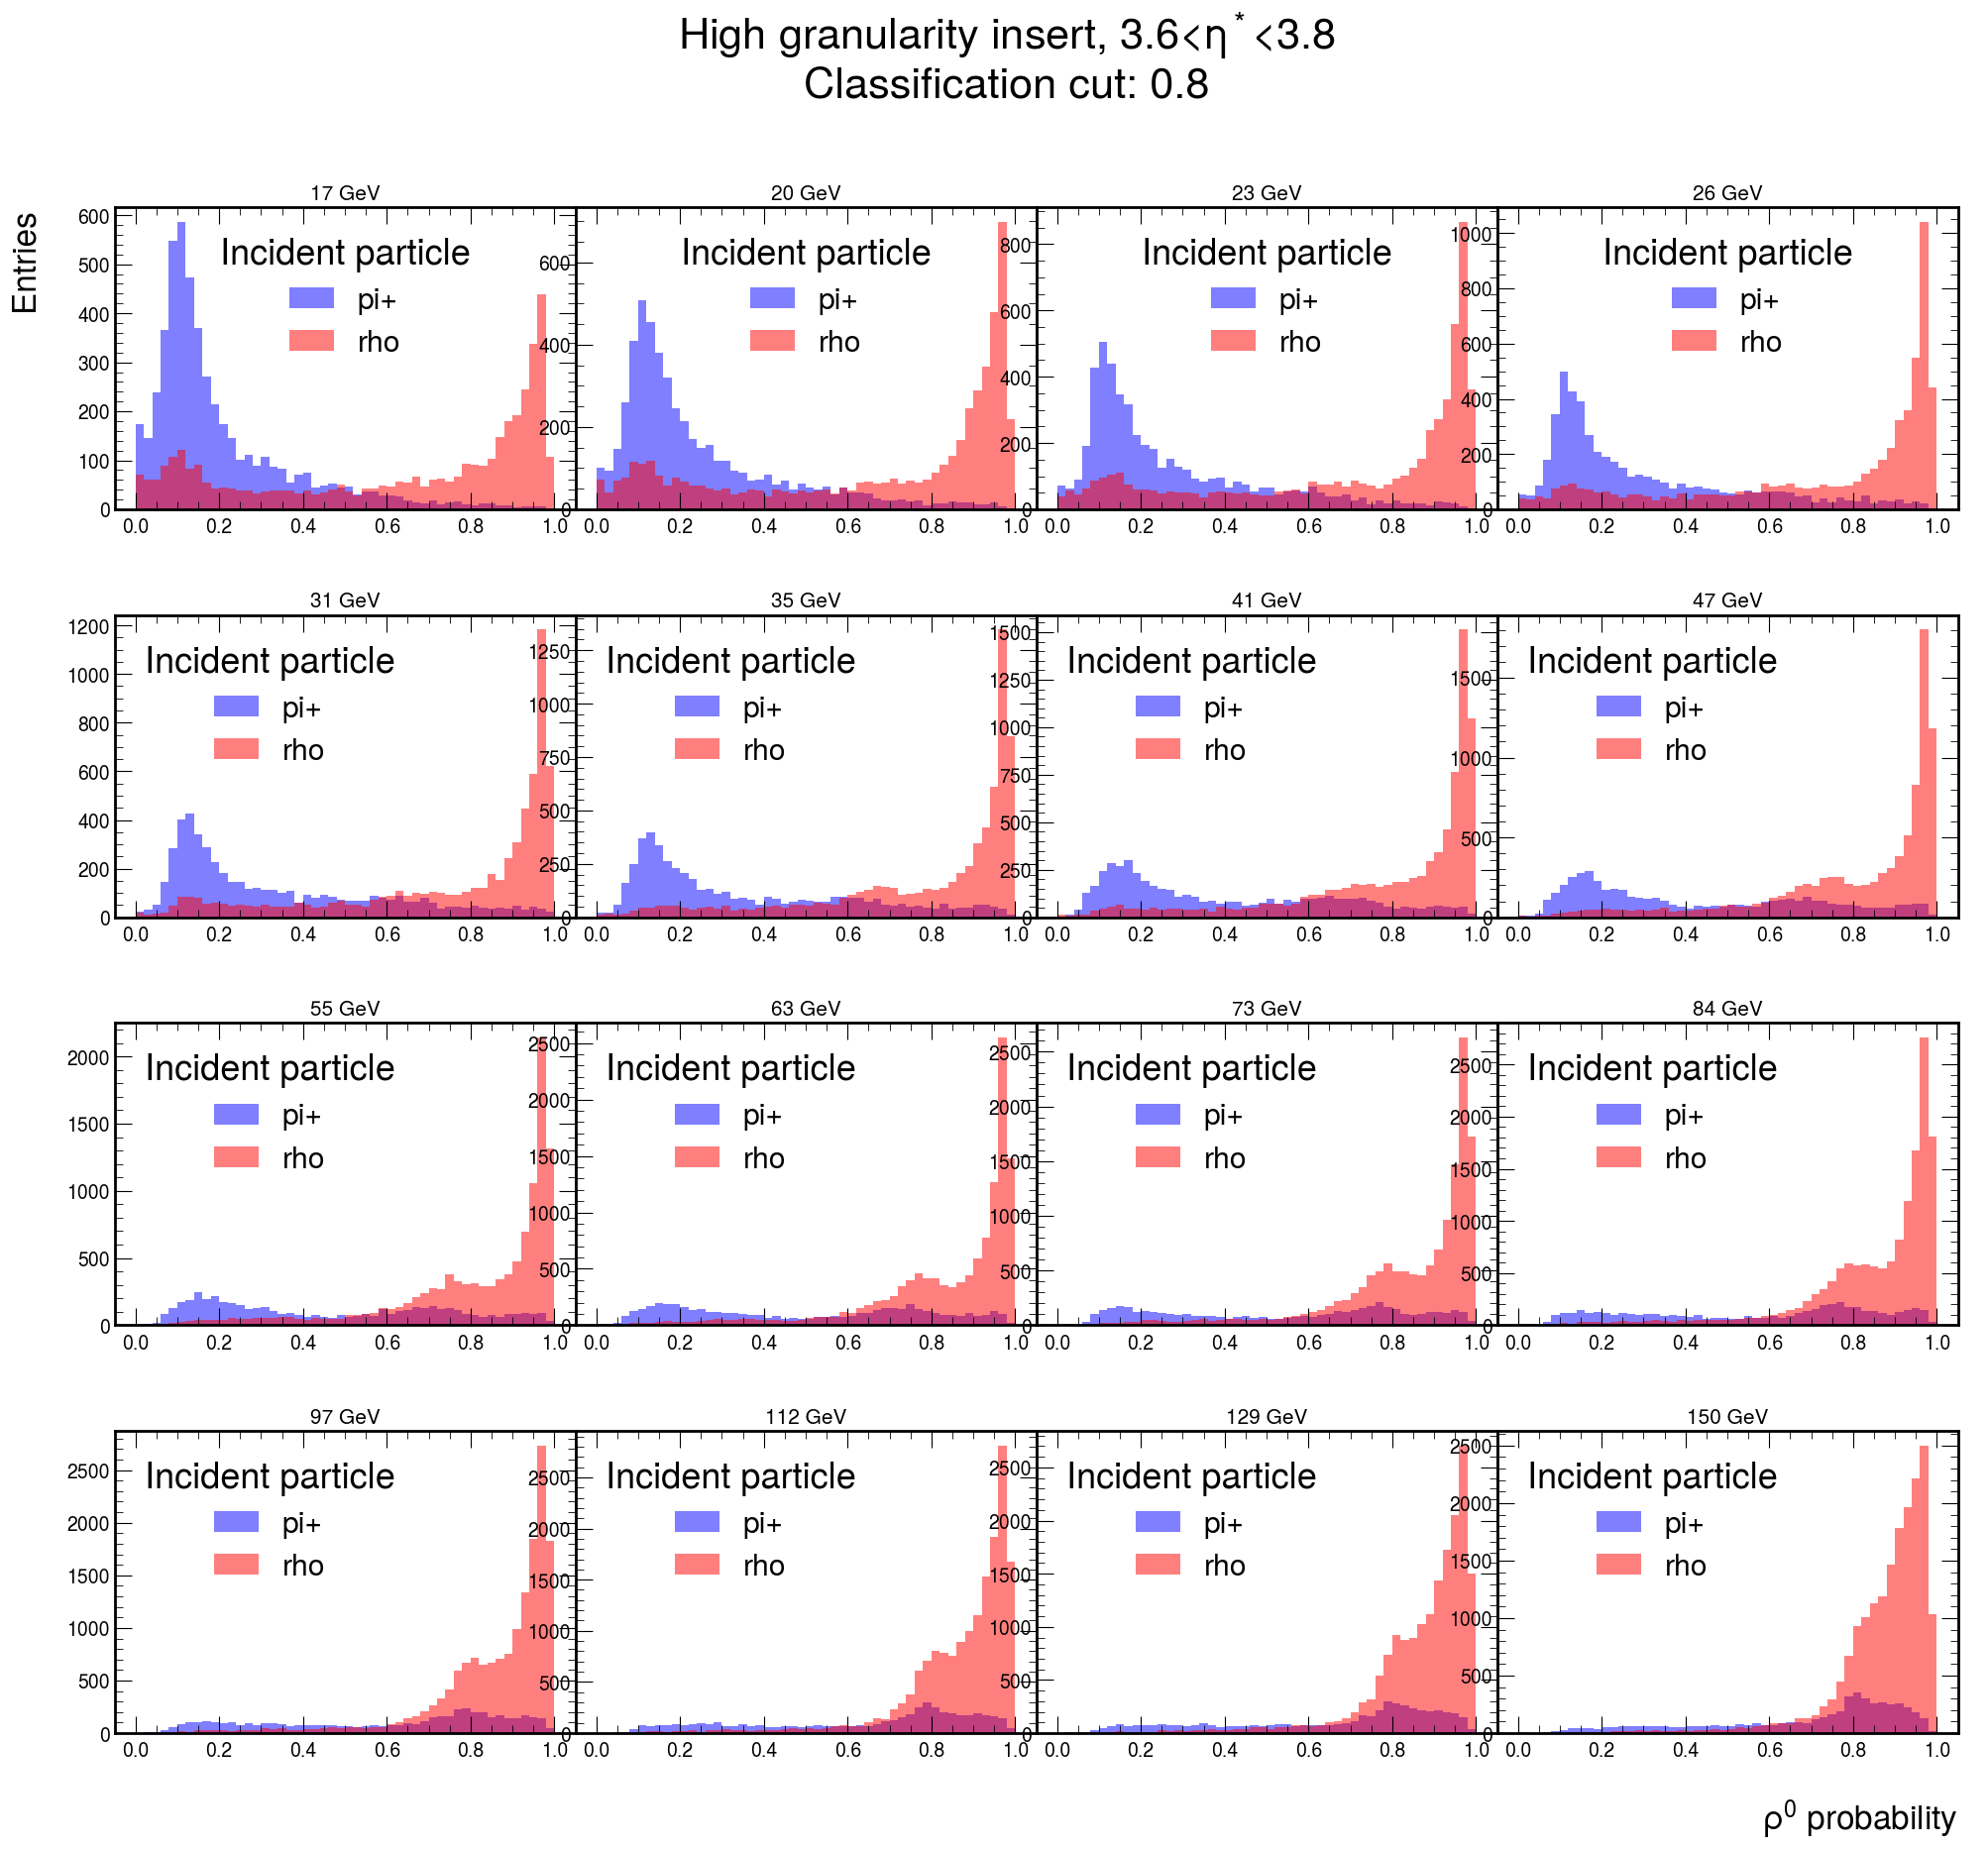

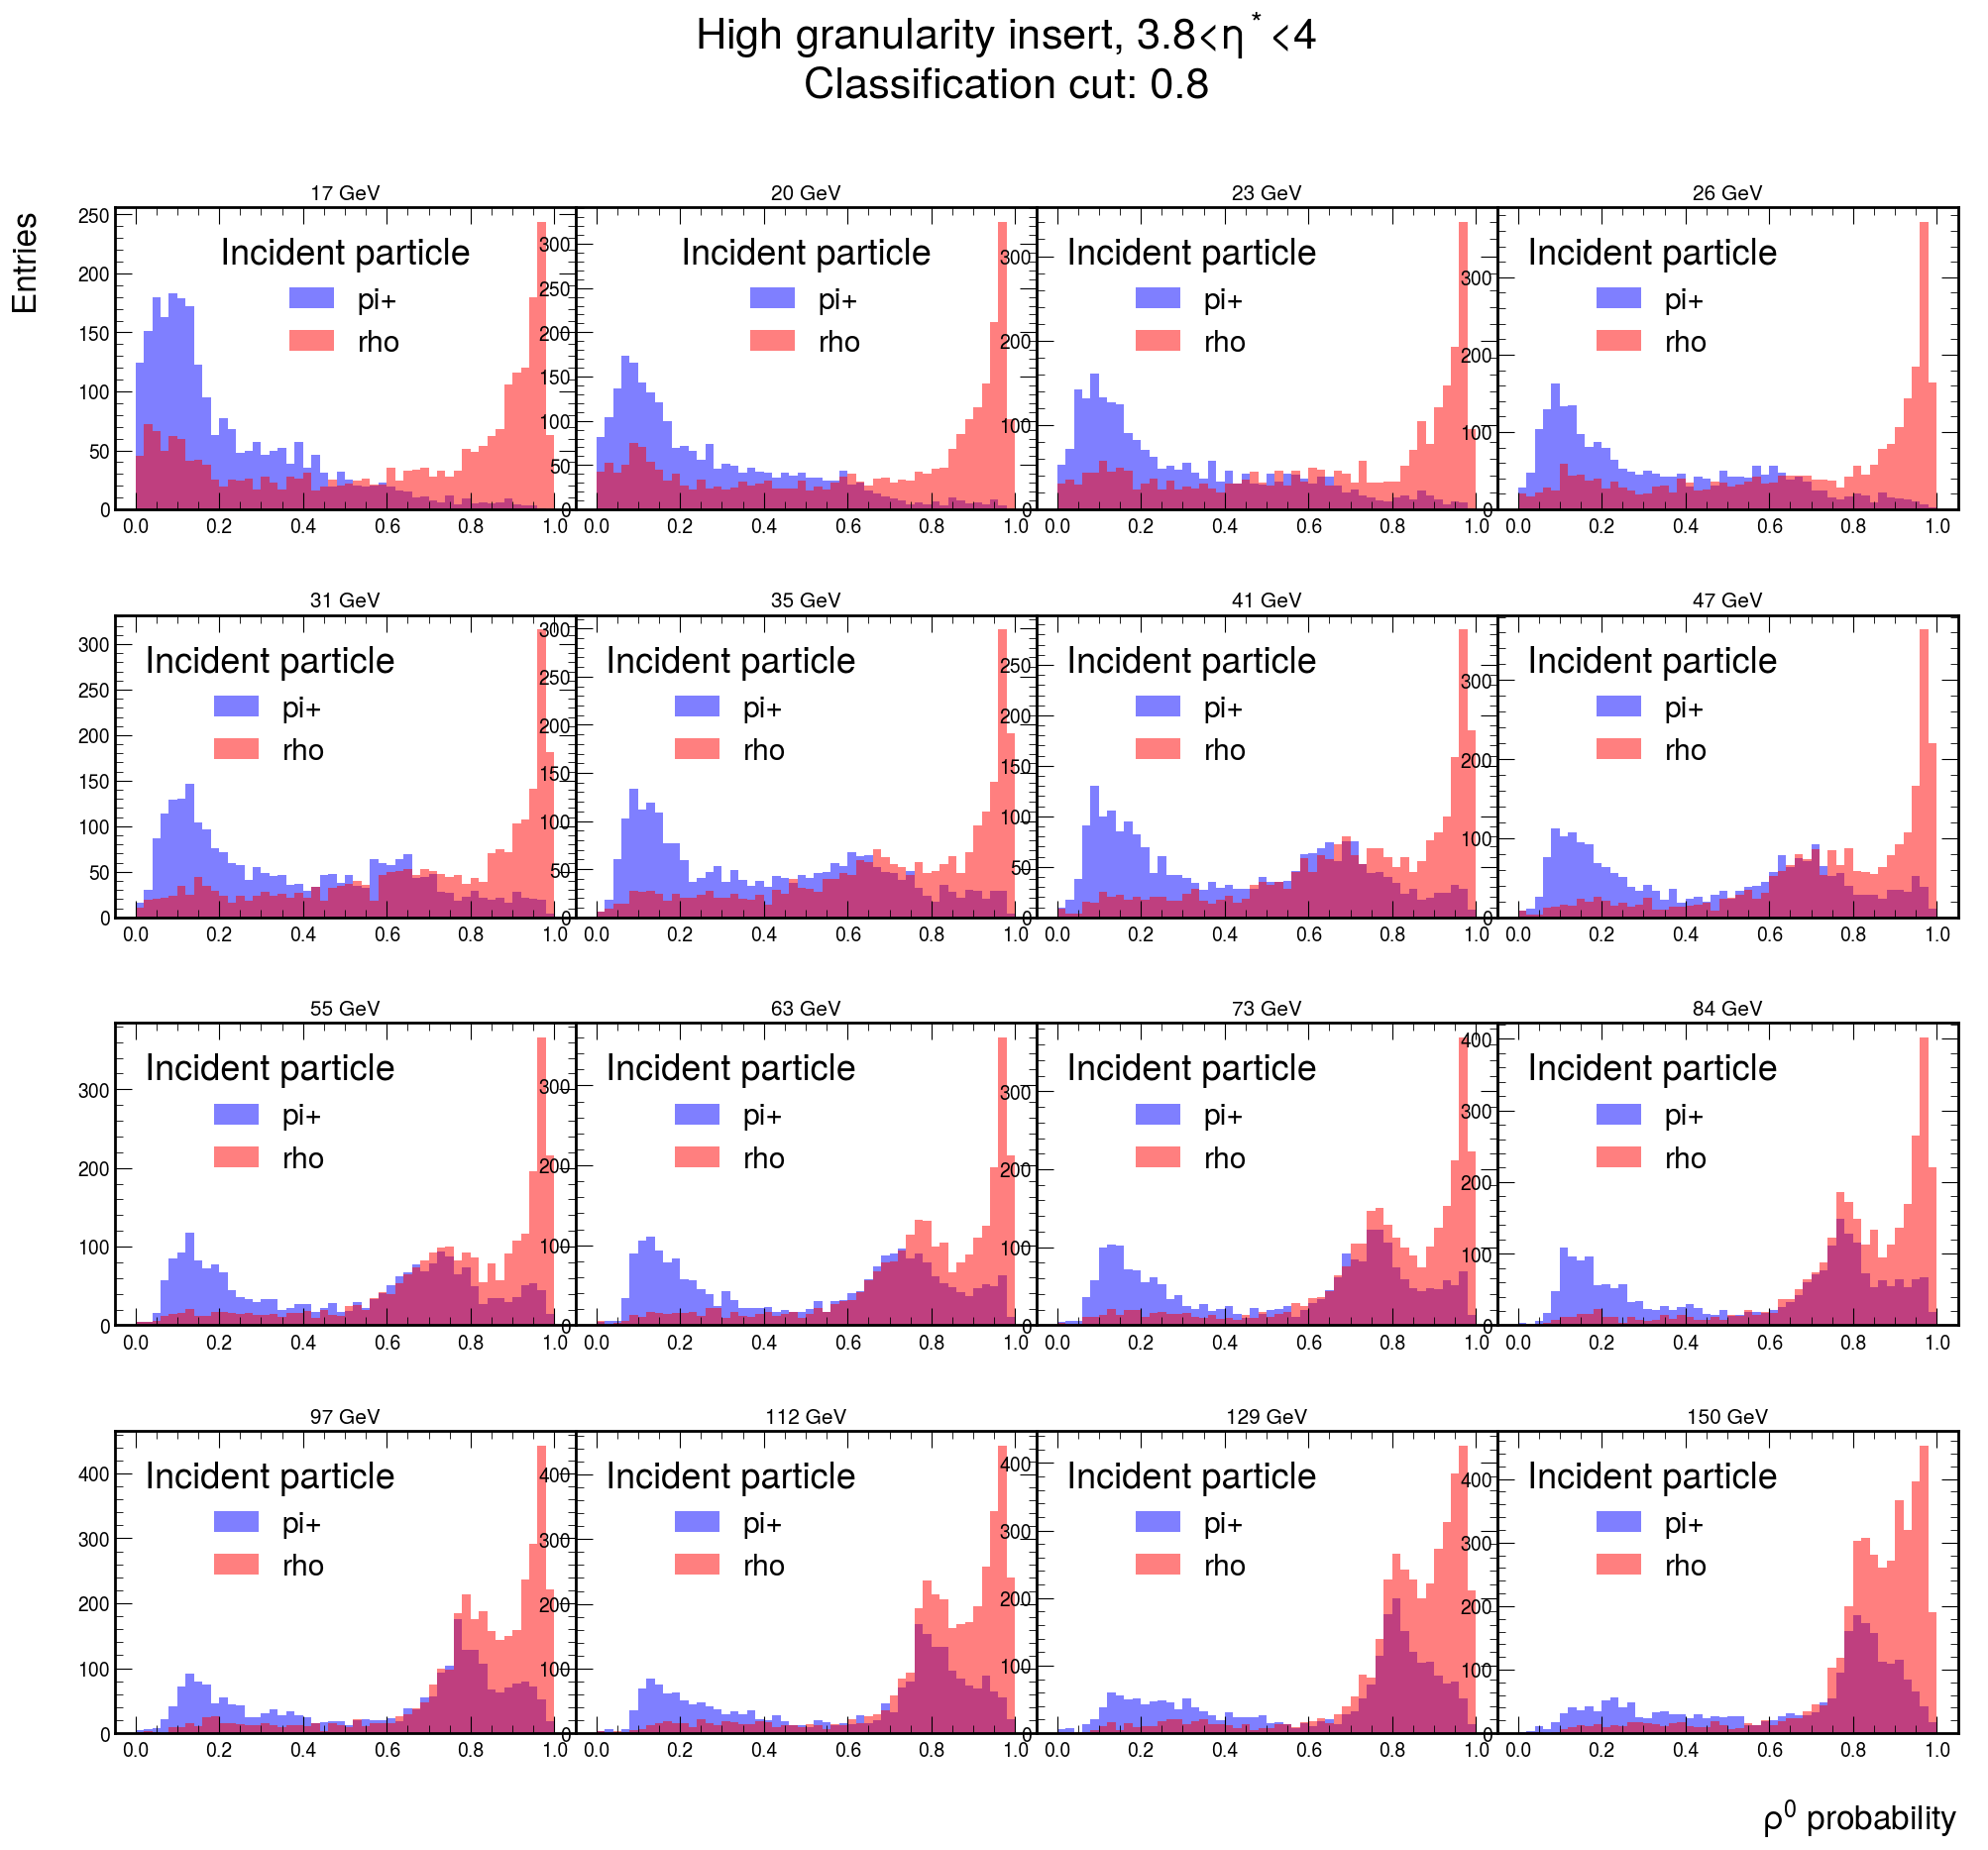

In [12]:
eta_bins = [(3.2, 3.4), (3.4,3.6), (3.6,3.8),(3.8, 4)]
nbins=50
id_cut = 0.8
pion_accuracy, rho_accuracy, classification_accuracy, pion_misidentification, rho_misidentification, classification_misidentification = [], [], [], [], [], []
for eta_bin in eta_bins:
    eta_low = eta_bin[0]
    eta_high = eta_bin[1]
    
    pion_accuracy_etabin, rho_accuracy_etabin, classification_accuracy_etabin,\
    pion_misidentification_etabin, rho_misidentification_etabin, classification_misidentification_etabin = plot_classification(
                                                                                 targets_energy,
                                                                                 targets_classification,
                                                                                 predictions_classification,
                                                                                 energy_bins,
                                                                                 nbins,
                                                                                 id_cut,
                                                                                 "pi+",
                                                                                 "rho",
                                                                                 eta,
                                                                                 eta_low,
                                                                                 eta_high
                                                                                 )
    pion_accuracy.append(pion_accuracy_etabin)
    rho_accuracy.append(rho_accuracy_etabin)
    classification_accuracy.append(classification_accuracy_etabin)
    pion_misidentification.append(pion_misidentification_etabin)
    rho_misidentification.append(rho_misidentification_etabin)
    classification_misidentification.append(classification_misidentification_etabin)
    
    if granularity=="high_granularity":
        plt.suptitle(f"High granularity insert, {eta_low}<$\eta^*$<{eta_high}\nClassification cut: {id_cut}")
    elif granularity=="low_granularity":
        plt.suptitle(f"Low granularity insert, {eta_low}<$\eta^*$<{eta_high}\nClassification cut: {id_cut}")
    

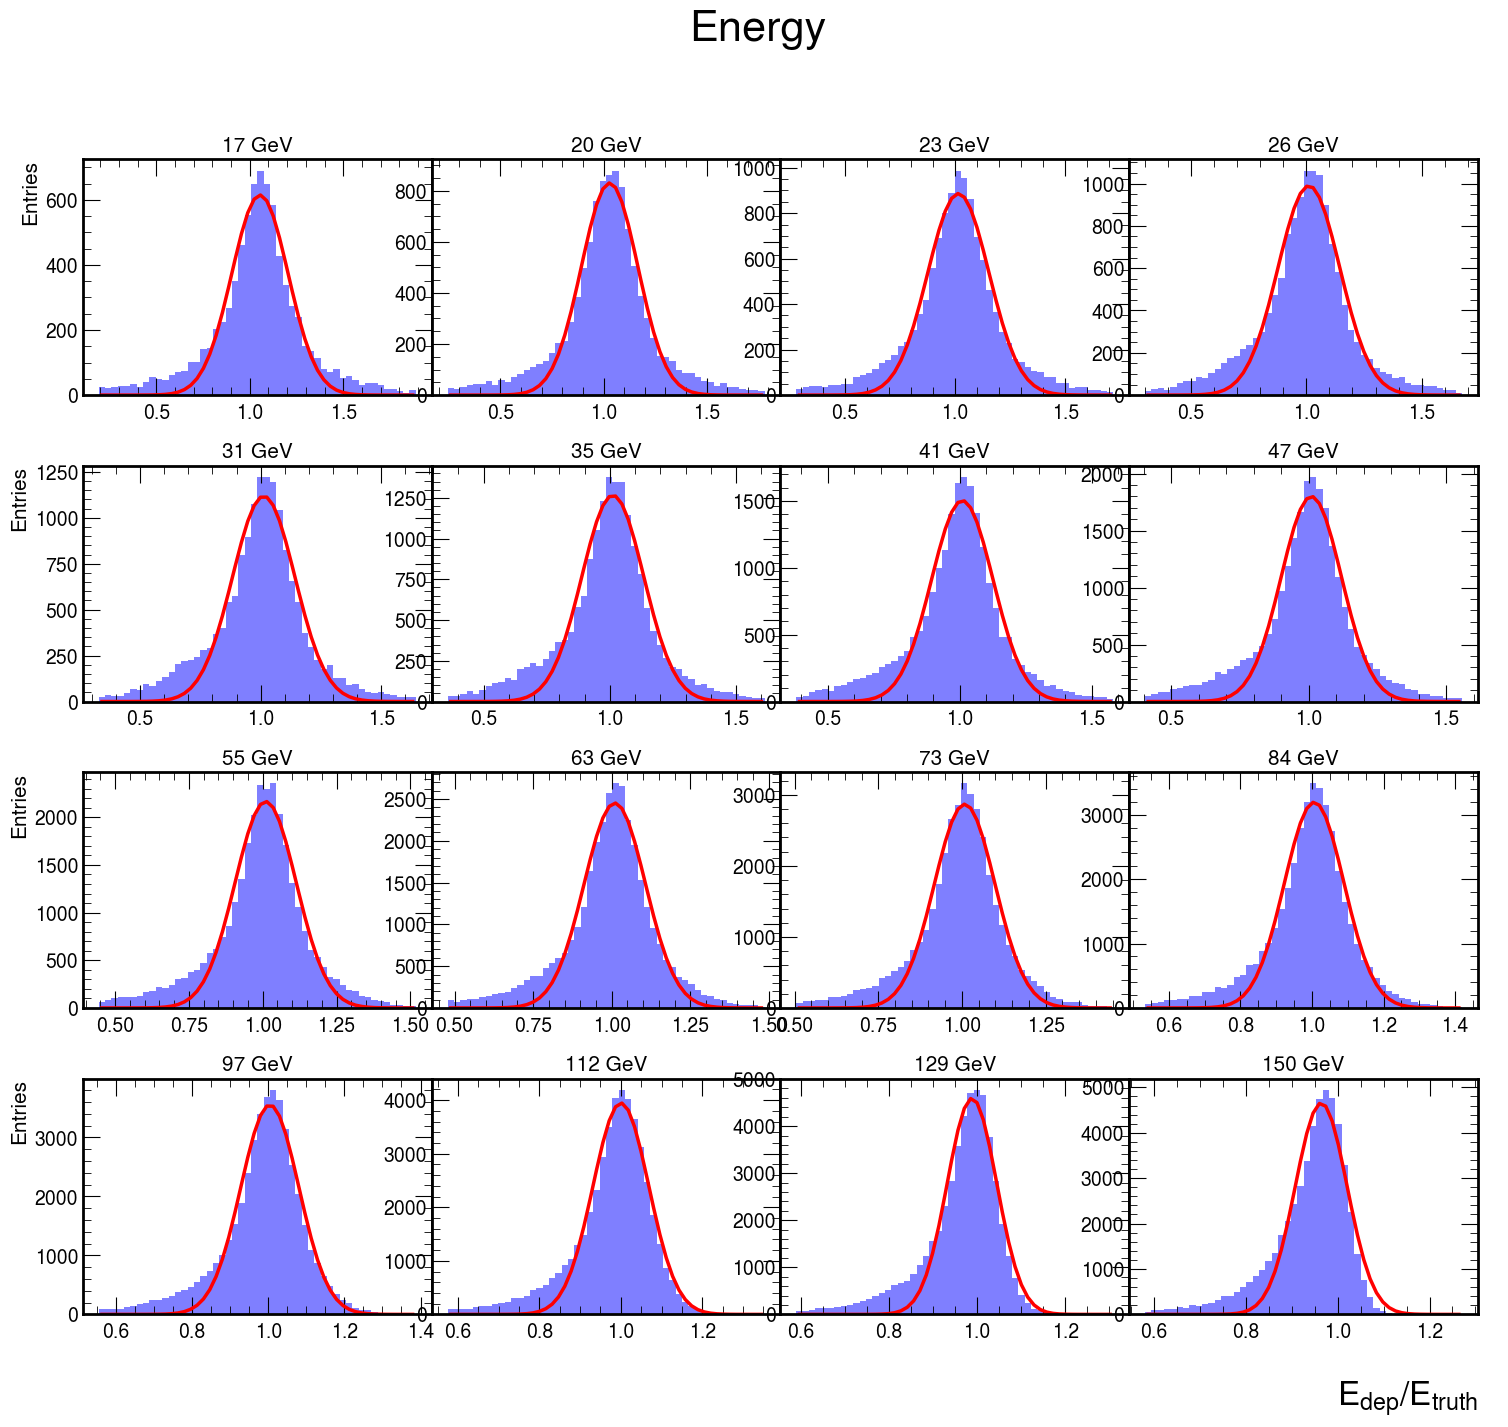

In [13]:
from helpers import get_resolutions
rho_mask = targets_classification==1
rho_energy_predictions = predictions_energy[rho_mask]
rho_energy_targets = targets_energy[rho_mask]
rho_truth_energies, rho_energy_resolutions, rho_energy_scales, rho_energy_leakage = get_resolutions(
            rho_energy_predictions,
            rho_energy_targets,
            energy_bins,
            nbins=50,
            data_name="energy",
            divide_by_genE=True,
            title=f"Energy"
        )

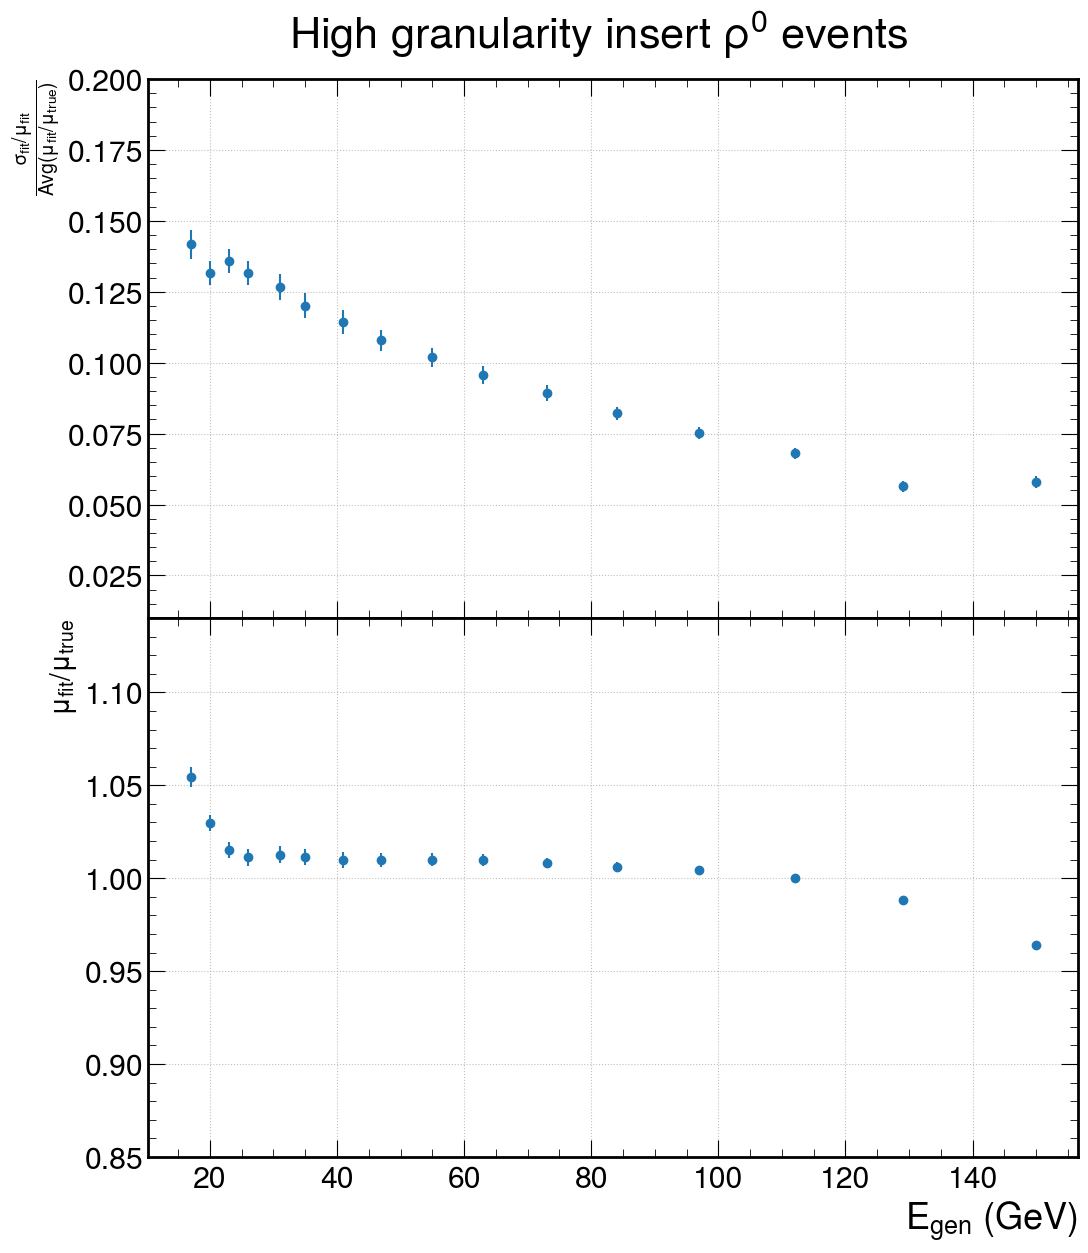

In [14]:
fig = plt.figure(figsize=(12,14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 1
truth_energy = rho_truth_energies
energy_mask = truth_energy>=lower_energy_lim
energy_resolution = rho_energy_resolutions[0]
energy_resolution_error = rho_energy_resolutions[1]

energy_scale = rho_energy_scales[0]
energy_scale_error = rho_energy_scales[1]

axs[0].errorbar(truth_energy[energy_mask],
                np.asarray(energy_resolution)[energy_mask],
                yerr = np.asarray(energy_resolution_error)[energy_mask],
                marker='o',
                linestyle='none',)
axs[0].set_ylabel("$\\frac{\sigma_{fit}/\mu_{fit}}{Avg (\mu_{fit}/\mu_{true})}$",  fontsize=20)
axs[0].set_ylim(0.01, .2)

axs[1].errorbar(truth_energy[energy_mask],
                np.asarray(energy_scale)[energy_mask],
                yerr = np.asarray(energy_scale_error)[energy_mask],
                marker='o',
                linestyle='none')
axs[1].set_ylim(.85, 1.14)

axs[1].set_ylabel("$\mu_{fit}/\mu_{true}$",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
if granularity=="high_granularity":
    plt.suptitle("High granularity insert $\\rho^0$ events", y=.93)
elif granularity=="low_granularity":
    plt.suptitle("Low granularity insert $\\rho^0$ events", y=.93)

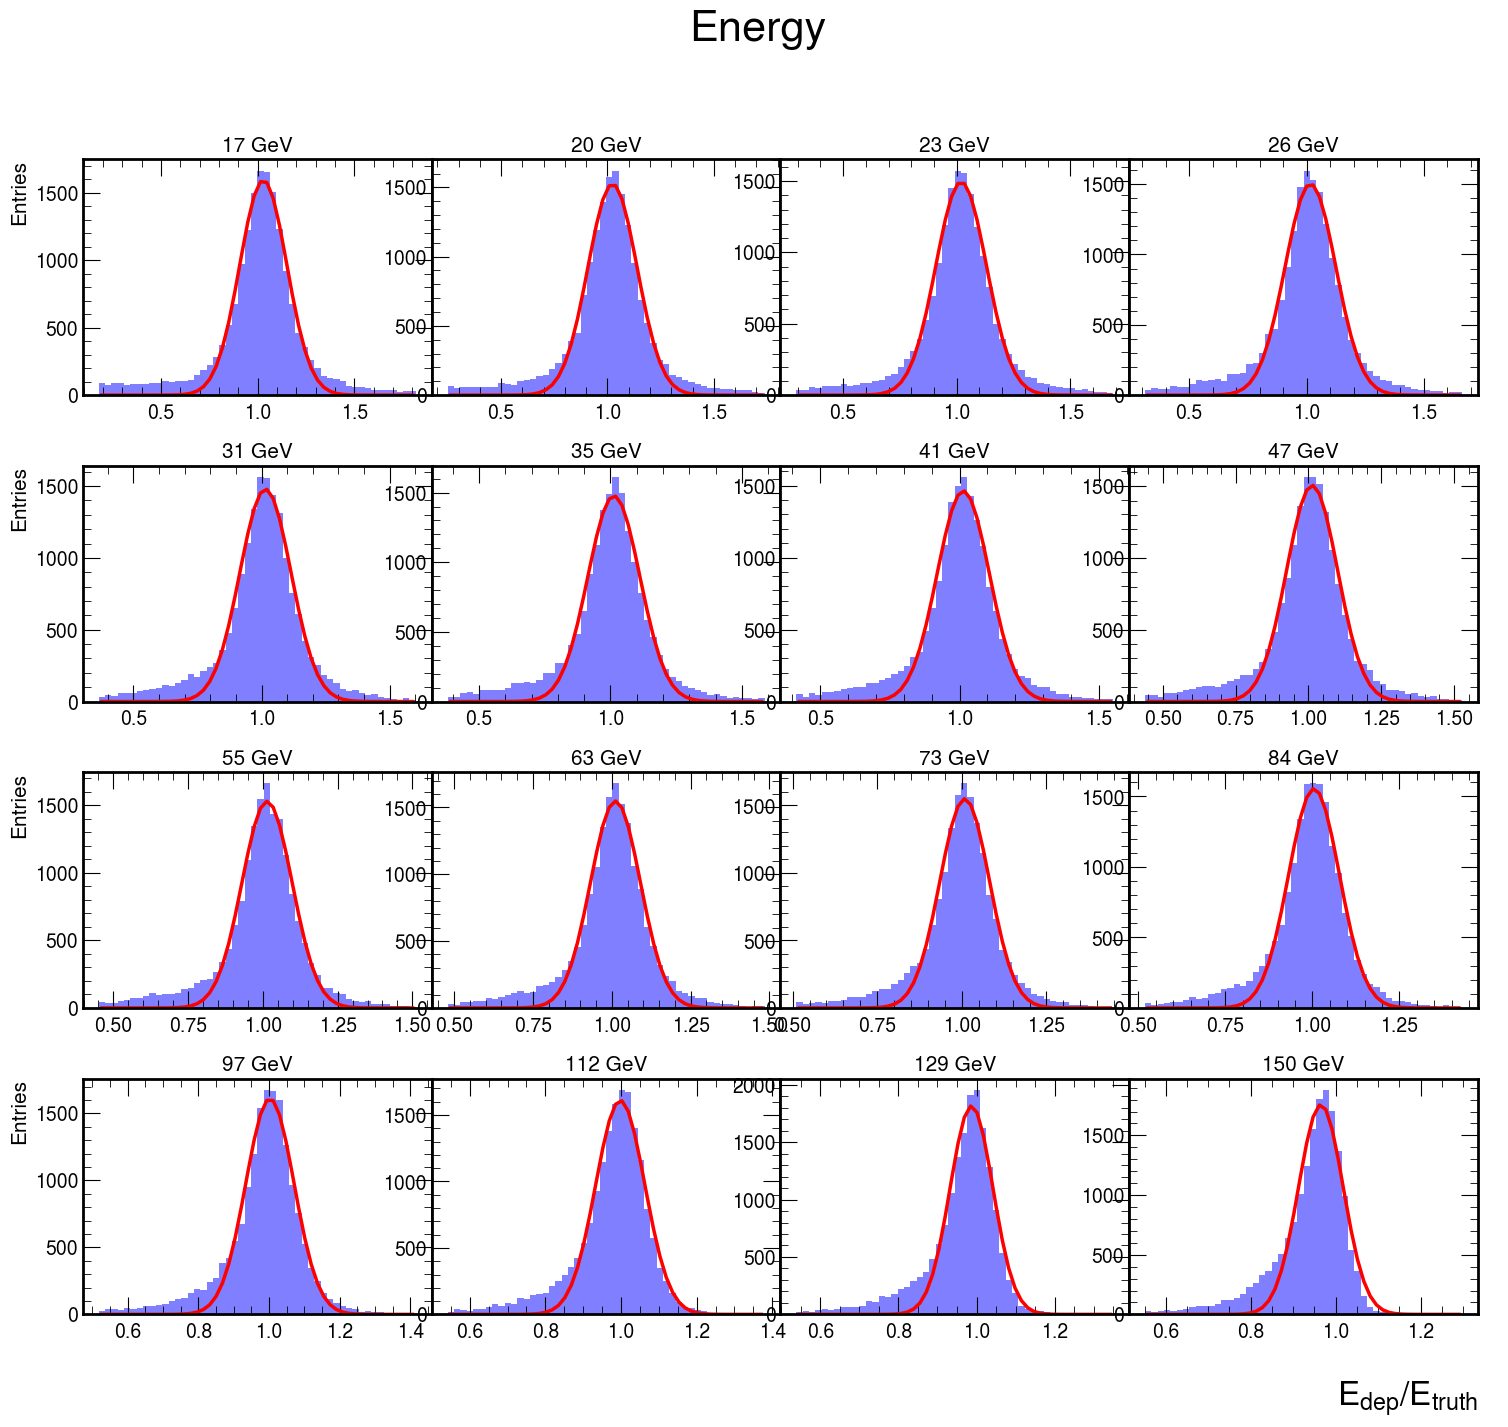

In [15]:
from helpers import get_resolutions
pion_mask = targets_classification==0
pion_energy_predictions = predictions_energy[pion_mask]
pion_energy_targets = targets_energy[pion_mask]
pion_truth_energies, pion_energy_resolutions, pion_energy_scales, pion_energy_leakage = get_resolutions(
            pion_energy_predictions,
            pion_energy_targets,
            energy_bins,
            nbins=50,
            data_name="energy",
            divide_by_genE=True,
            title=f"Energy"
        )

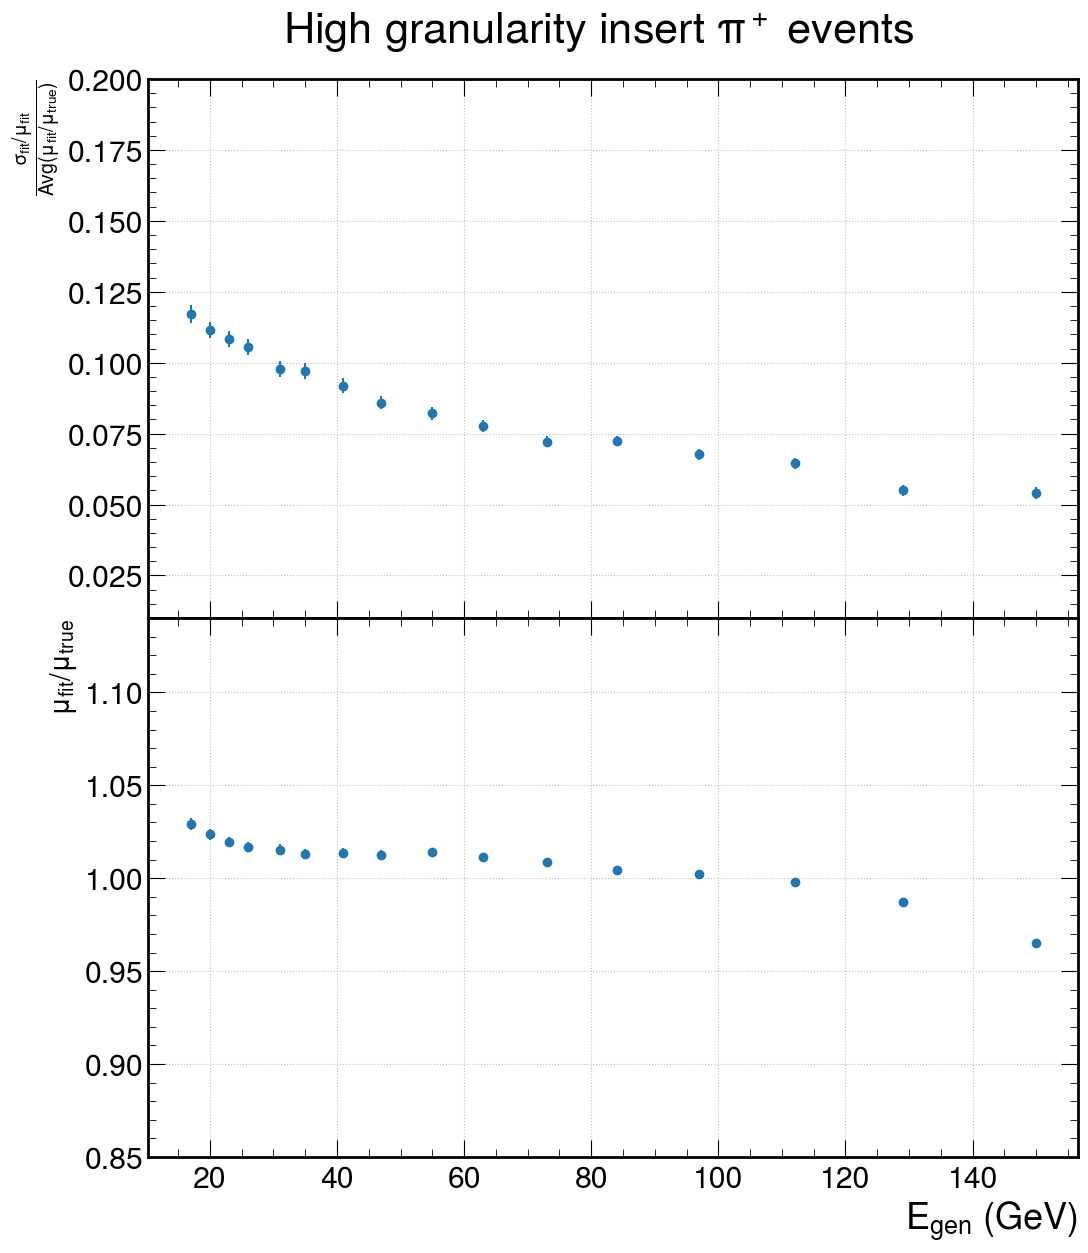

In [16]:
fig = plt.figure(figsize=(12,14))
fig.set_facecolor('w')
gs = fig.add_gridspec(2, hspace=0)
axs = gs.subplots(sharex=True, sharey=False)

lower_energy_lim = 1
truth_energy = pion_truth_energies
energy_mask = truth_energy>=lower_energy_lim
energy_resolution = pion_energy_resolutions[0]
energy_resolution_error = pion_energy_resolutions[1]

energy_scale = pion_energy_scales[0]
energy_scale_error = pion_energy_scales[1]

axs[0].errorbar(truth_energy[energy_mask],
                np.asarray(energy_resolution)[energy_mask],
                yerr = np.asarray(energy_resolution_error)[energy_mask],
                marker='o',
                linestyle='none',)
axs[0].set_ylabel("$\\frac{\sigma_{fit}/\mu_{fit}}{Avg (\mu_{fit}/\mu_{true})}$",  fontsize=20)
axs[0].set_ylim(0.01, .2)

axs[1].errorbar(truth_energy[energy_mask],
                np.asarray(energy_scale)[energy_mask],
                yerr = np.asarray(energy_scale_error)[energy_mask],
                marker='o',
                linestyle='none')
axs[1].set_ylim(.85, 1.14)

axs[1].set_ylabel("$\mu_{fit}/\mu_{true}$",  fontsize=20)
axs[1].set_xlabel("$E_{gen}$ (GeV)")
axs[0].grid()
axs[1].grid()
if granularity=="high_granularity":
    plt.suptitle("High granularity insert $\pi^+$ events", y=.93)
elif granularity=="low_granularity":
    plt.suptitle("Low granularity insert $\pi^+$ events", y=.93)

ValueError: x and y must have same first dimension, but have shapes (16,) and (400, 16)

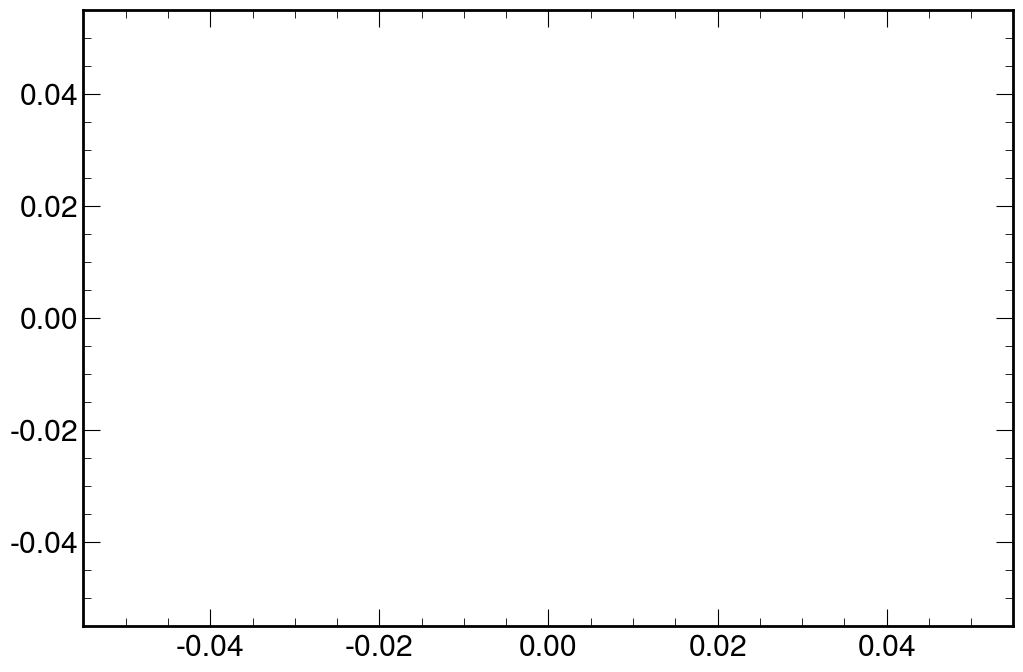

In [17]:
# Model's accuracy of classifying neutron (lambda) events as neutron (lambda)
fig = plt.figure(figsize = (12,8))
fig.set_facecolor('w')
plt.plot()
plt.plot(energy_bins, pion_accuracy * 100, label = '$\pi^+$', color = 'b')
plt.plot(energy_bins, rho_accuracy * 100, label = '$\\rho^0$', color = 'r')
plt.plot(energy_bins, classification_accuracy * 100, label='Total', color = 'g') # Overall accuracy for both photon & pi0


plt.xlabel('$E_{truth}$ [GeV]', fontsize = 20)
plt.ylabel('Classification accuracy (%) ',  fontsize = 20)
plt.legend(fontsize="20")
plt.xlim(50,100)
plt.grid()



In [ ]:
# energy_mask = (energy_bins > 90) & (energy_bins <250)
# print("Energies")
# print(energy_bins[energy_mask])
# print("Lambda efficiency")
# print(lambda_accuracy[energy_mask]*100)
# print("Neutron efficiency")
# print(neutron_misidentification[energy_mask]*100)

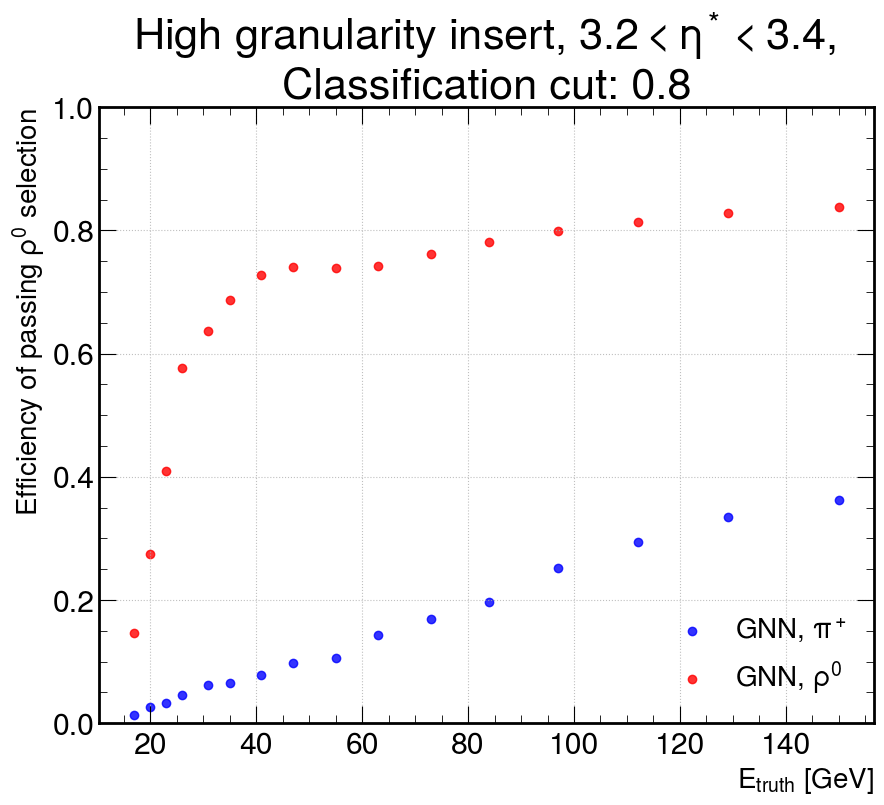

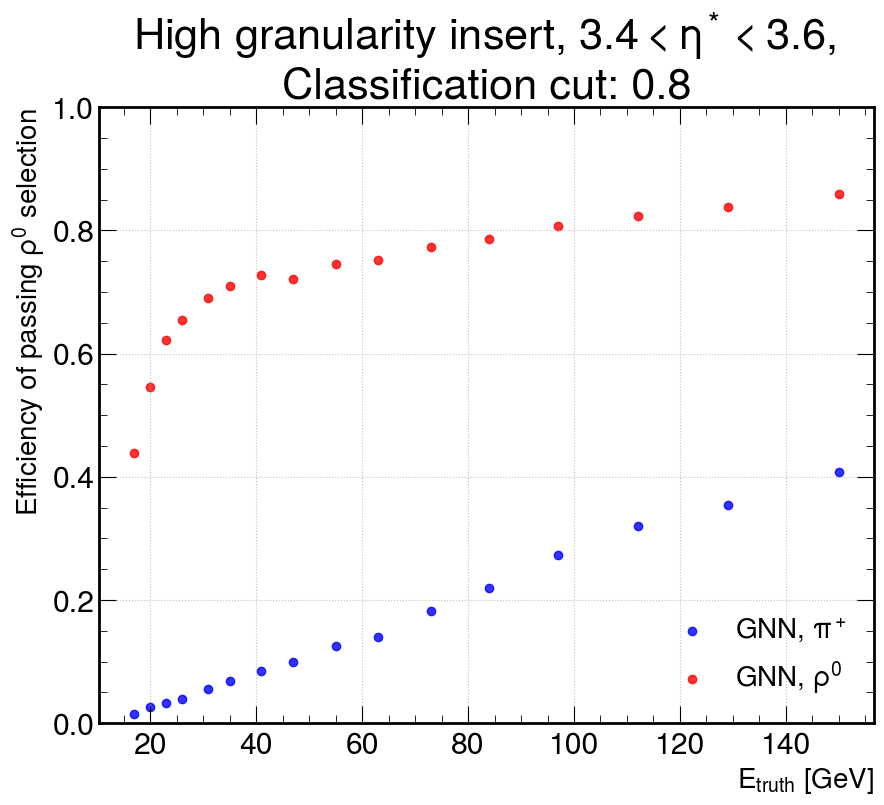

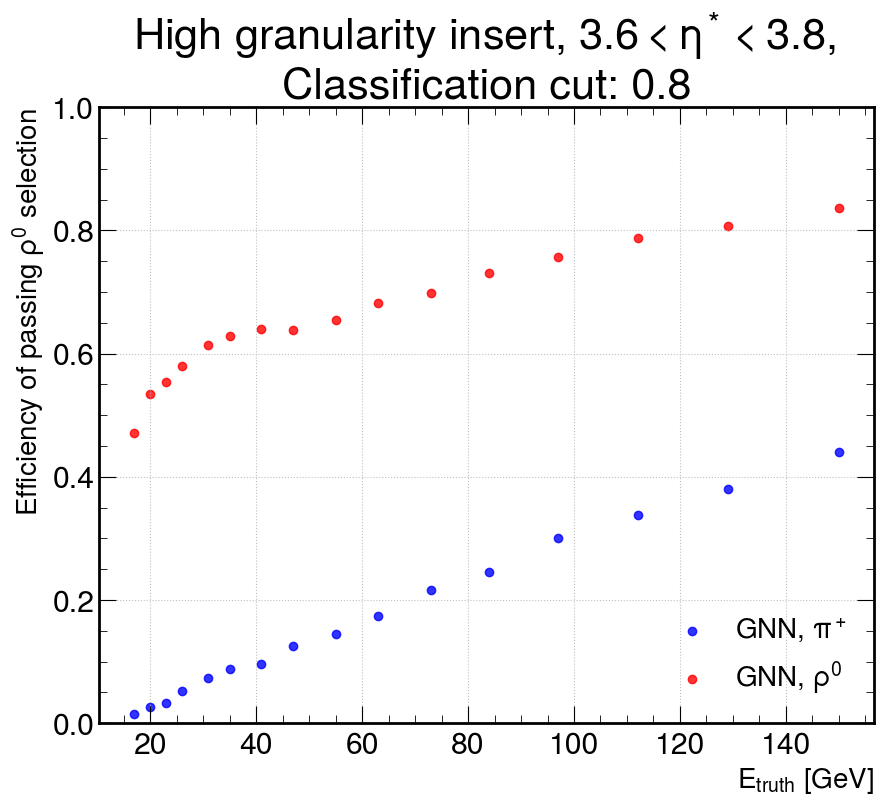

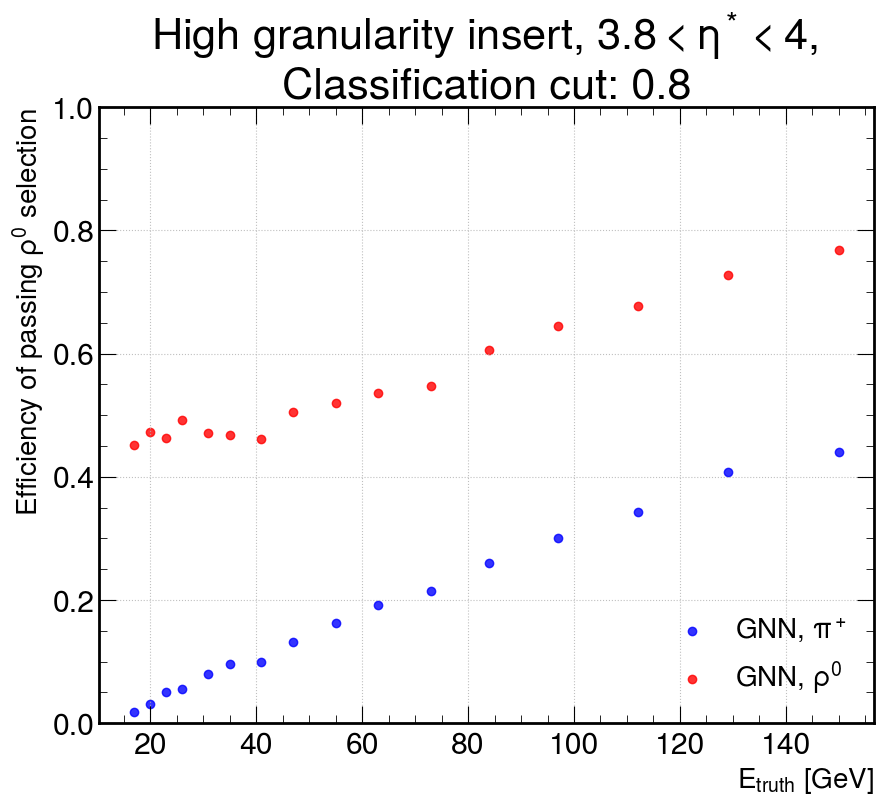

In [18]:
for i, eta_bin in enumerate(eta_bins):
    
    # Model's efficiency for events passing photon cut
    # i.e. Fraction of events the model classified photons as photons, pi0 as photons 
    fig = plt.figure(figsize=(10,8))
    fig.set_facecolor('w')
    plt.scatter(energy_bins, pion_misidentification[i], label='GNN, $\pi^+$', color='b', alpha=.8)
    plt.scatter(energy_bins, rho_accuracy[i], label='GNN, $\\rho^0$', color='r',alpha=.8)
    # plt.yscale("log")
    plt.ylim(0,1)

    # plt.xlim(100, 250)
    plt.xlabel('$E_{truth}$ [GeV]', fontsize=20)
    plt.ylabel('Efficiency of passing $\\rho^0$ selection', fontsize=20)
    plt.legend(fontsize="20", loc = 'lower right')
    if granularity=="high_granularity":
        plt.title(f"High granularity insert, ${eta_bin[0]}<\eta^*<{eta_bin[1]}$, \nClassification cut: {id_cut}")
    elif granularity=="low_granularity":
        plt.title(f"Low granularity insert, ${eta_bin[0]}<\eta^*<{eta_bin[1]}$\nClassification cut: {id_cut}")
    plt.grid()


In [ ]:
# Model's efficiency for events passing photon cut
# i.e. Fraction of events the model classified photons as photons, pi0 as photons 
fig = plt.figure(figsize=(10,8))
fig.set_facecolor('w')
plt.scatter(energy_bins, pion_misidentification, label='GNN, $\pi^+$', color='b', alpha=.8)
plt.scatter(energy_bins, rho_accuracy, label='GNN, $\\rho^0$', color='r',alpha=.8)
# plt.yscale("log")
plt.ylim(0,1)

# plt.xlim(100, 250)
plt.xlabel('$E_{truth}$ [GeV]', fontsize=20)
plt.ylabel('Efficiency of passing $\\rho^0$ selection', fontsize=20)
plt.legend(fontsize="20", loc = 'lower right')
if granularity=="high_granularity":
    plt.title(f"High granularity insert\nClassification cut: {id_cut}")
elif granularity=="low_granularity":
    plt.title(f"Low granularity insert\nClassification cut: {id_cut}")
plt.grid()
